# 02 - Classical and Imbalance-Aware Models

Temporal CV compares weighting, leakage-safe SMOTE, boosting and balanced ensembles. The winner is selected on a later validation block.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
ART = ROOT / 'artifacts'
FIG = ROOT / 'reports' / 'figures'
pd.set_option('display.max_columns', 100)


In [2]:
cv = pd.read_csv(ART / 'temporal_cv_results.csv')
cv.sort_values('cv_pr_auc_mean', ascending=False).head(15)

Out[0]: 
                                     candidate                  family  \
0                    xgboost__scale_pos_weight                 xgboost   
1                    xgboost__scale_pos_weight                 xgboost   
2   balanced_random_forest__balanced_bootstrap  balanced_random_forest   
3   balanced_random_forest__balanced_bootstrap  balanced_random_forest   
4                   lightgbm__scale_pos_weight                lightgbm   
5                              logistic__smote                logistic   
6                              logistic__smote                logistic   
7                   lightgbm__scale_pos_weight                lightgbm   
8                              logistic__smote                logistic   
9                              logistic__smote                logistic   
10        easy_ensemble__random_under_sampling           easy_ensemble   
11                      logistic__class_weight                logistic   
12                      logis

In [3]:
validation = pd.read_csv(ART / 'model_validation_comparison.csv')
validation.sort_values('validation_pr_auc', ascending=False)

Out[0]: 
                                    candidate                  family  \
0  balanced_random_forest__balanced_bootstrap  balanced_random_forest   
1                      logistic__class_weight                logistic   
2                   xgboost__scale_pos_weight                 xgboost   
3        easy_ensemble__random_under_sampling           easy_ensemble   
4                             logistic__smote                logistic   
5                        logistic__unweighted                logistic   
6                  lightgbm__scale_pos_weight                lightgbm   

                strategy                                             params  \
0     balanced_bootstrap             {"max_depth": 10, "n_estimators": 220}   
1           class_weight                                         {"C": 0.2}   
2       scale_pos_weight  {"learning_rate": 0.04, "max_depth": 5, "n_est...   
3  random_under_sampling                                {"n_estimators": 8}   
4          

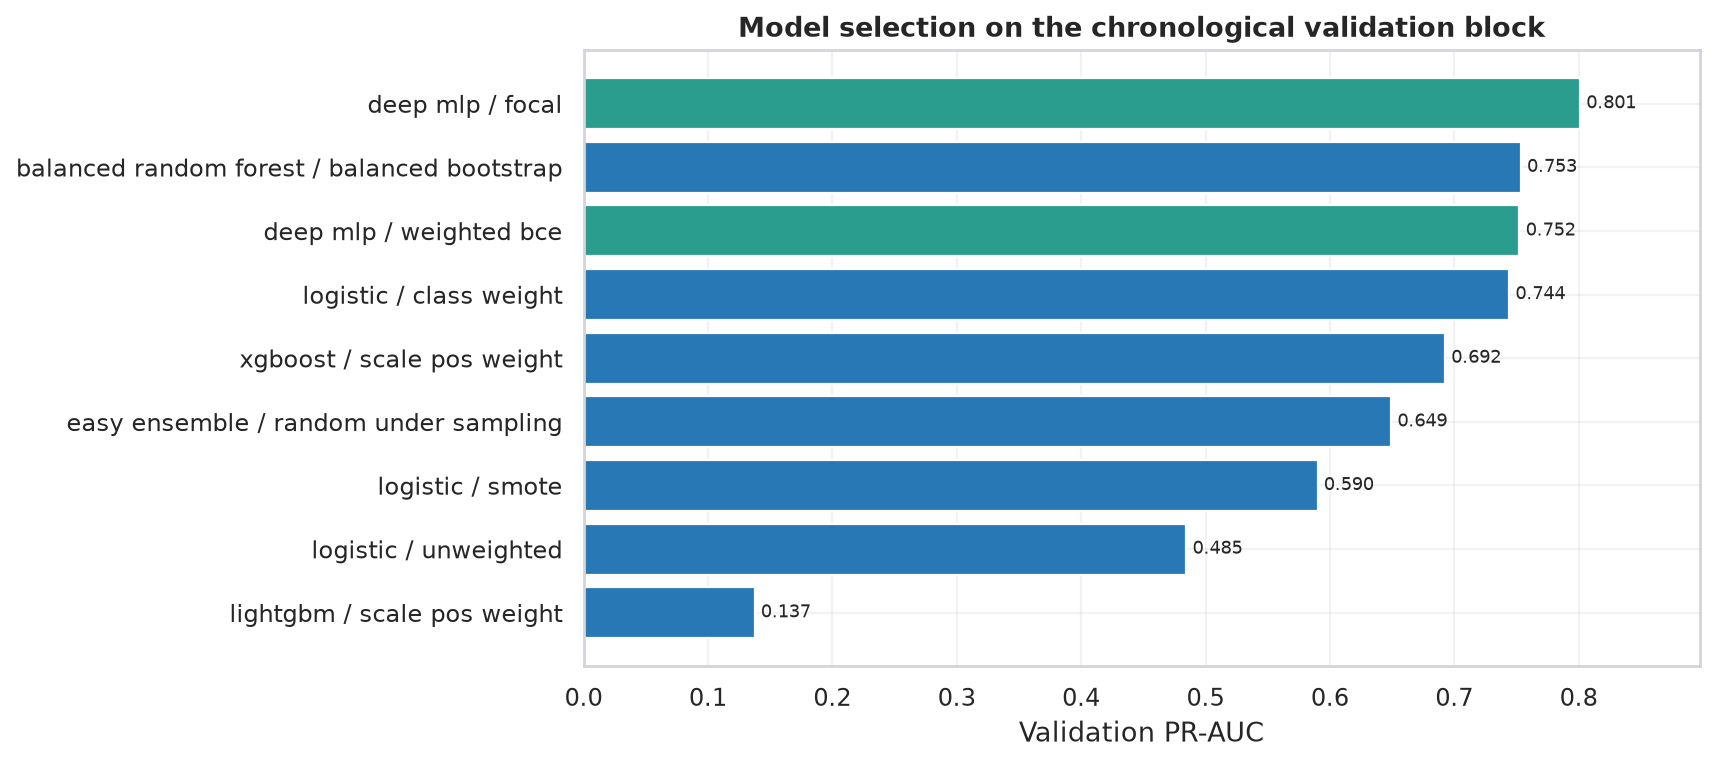

In [4]:
display(Image(filename=str(FIG / '03_model_validation.png')))

In [5]:
json.loads((ART / 'selected_model.json').read_text())

Out[0]: 
{'selected_candidate': 'deep_mlp__focal',
 'family': 'deep_mlp',
 'strategy': 'focal',
 'params': {'epochs': 13},
 'selection_metric': 'validation_pr_auc',
 'validation_pr_auc': 0.8010497327960754,
 'feature_names': ['V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6',
  'V7',
  'V8',
  'V9',
  'V10',
  'V11',
  'V12',
  'V13',
  'V14',
  'V15',
  'V16',
  'V17',
  'V18',
  'V19',
  'V20',
  'V21',
  'V22',
  'V23',
  'V24',
  'V25',
  'V26',
  'V27',
  'V28',
  'Amount',
  'LogAmount',
  'HourSin',
  'HourCos']}


The strategy comparison is connected to model selection: the best hyperparameter configuration within each family/strategy proceeds to validation, and the validation winner alone feeds calibration and the decision system.